# Construct an island-inpainted global ERA5 + SCOTIA forcing dataset

This notebook is an experimental variant of `construct_forcing_dataset.ipynb`. It preserves the canonical forcing contract and physical constants, but removes land-stress discontinuities at islands that the reduced model does not explicitly represent.

GEBCO is aggregated onto each native $0.25^\circ$ ERA5 cell to identify cells containing land and the surrounding 1000 m shelf. Land cells more than the outer-boundary taper width inside the modelled ocean are treated as internal holes. Both ERA5 stress components are harmonically extended across those holes **before** anomalies, the outer-boundary taper, the Ekman conversion, and the divergence used by the model.

This ordering is deliberate: setting island stress or Ekman pumping to zero would create another sharp edge, whereas harmonic extension makes the forcing consistent with a reduced geometry that treats each basin branch as zonally uninterrupted.

The exported dataset contains the same three variables as the canonical forcing:

- `M_Ek_x(time, latitude, longitude)` in $\mathrm{m^2\,s^{-1}}$;
- `M_Ek_y(time, latitude, longitude)` in $\mathrm{m^2\,s^{-1}}$; and
- `T_N(time)` in $\mathrm{m^3\,s^{-1}}$.

The native ERA5 grid and the existing outer solid-boundary taper are retained. Generated data are written beneath `data/untracked/forcing/`.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("KMP_WARNINGS", "0")

import dask
import dask.array as da
from dask import delayed
from dask.diagnostics import ProgressBar
import matplotlib.pyplot as plt
from netCDF4 import Dataset as NetCDFDataset
import numpy as np
from scipy import ndimage, optimize, sparse
from scipy.sparse.linalg import spsolve
import xarray as xr

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = REPO_ROOT / "data" / "untracked"
ISOBATH_PATH = REPO_ROOT / "data" / "tracked" / "isobath" / "global_isobath_GEBCO_1000m.nc"
GEBCO_PATH = DATA_ROOT / "GEBCO" / "GEBCO_2026_sub_ice" / "GEBCO_2026_sub_ice.nc"
WINDS_PATH = DATA_ROOT / "ERA5" / "global_winds.nc"
SCOTIA_PATH = DATA_ROOT / "SCOTIA" / "SCOTIA_overturning_diagnostics.nc"
OUTPUT_PATH = DATA_ROOT / "forcing" / "global_ERA5_SCOTIA_forcing_island_inpainted.nc"

for path in (ISOBATH_PATH, GEBCO_PATH, WINDS_PATH, SCOTIA_PATH):
    if not path.exists():
        raise FileNotFoundError(f"Required input does not exist: {path}")

print(f"Repository: {REPO_ROOT}")
print(f"Output:     {OUTPUT_PATH}")

Repository: /private/tmp/MOCAdjustmentTheory-island-inpaint
Output:     /private/tmp/MOCAdjustmentTheory-island-inpaint/data/untracked/forcing/global_ERA5_SCOTIA_forcing_island_inpainted.nc


## Physical and numerical choices

The physical constants, equatorial regularization, native grid, and outer-boundary taper match the canonical forcing notebook. `TAPER_K = 0.5 degree^-1` gives a two-degree transition into the active ocean.

GEBCO land presence is aggregated over the complete footprint of every ERA5 cell, rather than sampled only at its centre, so small islands are retained. An internal land cell must lie more than the taper width inside the active envelope. The inpainting mask also includes one neighbouring ERA5 cell where GEBCO finds bathymetry shallower than the active-layer depth. This replaces the island shelf transition while leaving the true outer-wall taper unchanged.

In [2]:
EARTH_ROTATION_RATE = 7.292115e-5  # rad s-1
EARTH_RADIUS = 6.371e6             # m
RHO_0 = 1027.0                     # kg m-3; upstream conversion choice
G_PRIME = 0.02                     # m s-2; sets the capped wave speed
ATLANTIC_NORTH = 55.0              # degrees north
TAPER_K = 0.5                      # degree-1; two-degree smooth transition
ERA5_WRAP_START = 280.0            # 280..360 becomes -80..0
ERA5_EAST_LIMIT = 290.0


def coriolis(latitude):
    """Coriolis parameter in inverse seconds."""
    return 2.0 * EARTH_ROTATION_RATE * np.sin(np.deg2rad(latitude))


def beta(latitude):
    """Meridional Coriolis gradient in inverse metres per second."""
    return (
        2.0
        * EARTH_ROTATION_RATE
        * np.cos(np.deg2rad(latitude))
        / EARTH_RADIUS
    )


def cap_latitude(g_prime, depth):
    """Latitude where the long Rossby speed reaches its gravity-wave cap."""
    gravity_wave_cap = np.sqrt(g_prime * depth) / 3.0
    return float(
        optimize.brentq(
            lambda latitude: (
                beta(latitude) * g_prime * depth / coriolis(latitude) ** 2
                - gravity_wave_cap
            ),
            1.0,
            30.0,
        )
    )


def smooth_ramp(scaled_distance):
    """C-infinity ramp: zero at distance <= 0 and one at distance >= 1."""
    scaled_distance = np.asarray(scaled_distance, dtype=float)
    result = np.zeros_like(scaled_distance)
    result[scaled_distance >= 1.0] = 1.0
    transition = (scaled_distance > 0.0) & (scaled_distance < 1.0)
    left = np.exp(-1.0 / scaled_distance[transition])
    right = np.exp(-1.0 / (1.0 - scaled_distance[transition]))
    result[transition] = left / (left + right)
    return result


def common_latitude_domain(dataset, *boundary_names):
    """Latitude interval on which every named boundary is finite."""
    valid = [dataset[name].dropna("latitude") for name in boundary_names]
    south = max(float(boundary.latitude[0]) for boundary in valid)
    north = min(float(boundary.latitude[-1]) for boundary in valid)
    if south >= north:
        raise ValueError(f"No common domain for {boundary_names}")
    return south, north

## Geometry and active latitude ranges

The five-region topology is represented on each latitude by one or more disjoint ocean intervals. South of the Pacific entrance there is one Atlantic-to-Pacific interval; between the Pacific and Indian entrances there is an Atlantic-to-Indian interval plus the Pacific; farther north there are separate Atlantic, Indian, and Pacific intervals.

In [3]:
isobath = xr.open_dataset(ISOBATH_PATH).dropna("latitude", how="all")
required_boundaries = {"x_wP", "x_wA", "x_wI", "x_eP", "x_eA", "x_eI"}
if set(isobath.data_vars) != required_boundaries:
    raise ValueError("Isobath dataset does not match the six-variable specification")

H = float(isobath.attrs["isobath_depth_m"])
y_S, _ = common_latitude_domain(isobath, "x_wA", "x_eP")
y_I, y_NI = common_latitude_domain(isobath, "x_wI", "x_eI")
y_P, y_NP = common_latitude_domain(isobath, "x_wP", "x_eP")
y_P = max(y_P, y_S)
_, y_NA_supported = common_latitude_domain(isobath, "x_wA", "x_eA")
global_north = max(ATLANTIC_NORTH, y_NI, y_NP) + 1.0 / TAPER_K
if global_north > y_NA_supported:
    raise ValueError("Atlantic geometry does not support the northern forcing halo")

phi_c = cap_latitude(G_PRIME, H)
gamma = float(coriolis(phi_c))
print(
    f"forcing domain: {y_S:.3f} to {global_north:.3f} deg; "
    f"T_N latitude {ATLANTIC_NORTH:.3f} deg; "
    f"Pacific entrance {y_P:.3f} deg; Indian entrance {y_I:.3f} deg; "
    f"Pacific/Indian north {y_NP:.3f}/{y_NI:.3f} deg"
)
print(f"H={H:g} m; cap latitude={phi_c:.3f} deg; gamma={gamma:.6e} s-1")

forcing domain: -55.075 to 61.358 deg; T_N latitude 55.000 deg; Pacific entrance -43.992 deg; Indian entrance -34.992 deg; Pacific/Indian north 59.358/24.658 deg
H=1000 m; cap latitude=6.877 deg; gamma=1.746177e-05 s-1


## Common monthly anomalies

SCOTIA timestamps are shifted from the monthly midpoint to the first day, matching ERA5 after its six-hour timestamp correction. Means are removed over their exact common record before any physical conversion.

In [4]:
scotia = xr.open_dataset(SCOTIA_PATH, chunks={}).moc
scotia = scotia.assign_coords(time=scotia.time - np.timedelta64(14, "D"))
scotia = scotia.astype(np.float64)
scotia_anomaly = scotia - scotia.mean("time")

winds_raw = xr.open_dataset(WINDS_PATH, chunks={})[["avg_iews", "avg_inss"]]
winds_raw = winds_raw.drop_vars(["expver", "number"], errors="ignore")
winds_raw = winds_raw.assign_coords(
    valid_time=winds_raw.valid_time - np.timedelta64(6, "h")
).rename(valid_time="time")

winds = xr.concat(
    [
        winds_raw.sel(longitude=slice(ERA5_WRAP_START, None)).assign_coords(
            longitude=lambda dataset: dataset.longitude - 360.0
        ),
        winds_raw.sel(longitude=slice(0.0, ERA5_EAST_LIMIT)),
    ],
    dim="longitude",
).sortby("longitude")
winds = winds.sel(latitude=slice(global_north, y_S)).sortby("latitude")
winds = winds.sel(time=scotia.time)
if not winds.time.equals(scotia.time):
    raise ValueError("ERA5 and SCOTIA do not share an exact monthly time grid")
winds = winds.chunk({"time": 12, "latitude": 32, "longitude": 128})

latitude = winds.latitude.values.astype(float)
longitude = winds.longitude.values.astype(float)
print(winds.sizes)

Frozen({'time': 246, 'latitude': 466, 'longitude': 1481})


## Smooth solid-boundary taper

The five topological intervals first define one binary active-ocean mask. A distance transform then produces one smooth taper from the complete two-dimensional solid boundary, so the taper follows continental tips rather than changing discontinuously between latitude sectors. The Indian and Pacific northern rows are included as solid boundaries. The open southern boundary and the Atlantic section at the prescribed `T_N` latitude are not boundaries of the taper. Latitude padding prevents the finite grid edges from being interpreted as solid.

In [5]:
boundary = isobath.interp(latitude=latitude)
active_layer = np.zeros((latitude.size, longitude.size), dtype=bool)


def include_interval(rows, west_name, east_name):
    west = boundary[west_name].values
    east = boundary[east_name].values
    valid = rows & np.isfinite(west) & np.isfinite(east)
    active_layer[valid] |= (
        (longitude[None, :] > west[valid, None])
        & (longitude[None, :] < east[valid, None])
    )


include_interval((latitude >= y_S) & (latitude < y_P), "x_wA", "x_eP")
include_interval((latitude >= y_P) & (latitude < y_I), "x_wA", "x_eI")
include_interval(latitude >= y_I, "x_wA", "x_eA")
include_interval((latitude >= y_I) & (latitude <= y_NI), "x_wI", "x_eI")
include_interval((latitude >= y_P) & (latitude <= y_NP), "x_wP", "x_eP")

latitude_step = float(np.diff(latitude).min())
longitude_step = float(np.diff(longitude).min())
if not np.allclose(np.diff(latitude), latitude_step) or not np.allclose(
    np.diff(longitude), longitude_step
):
    raise ValueError("The taper requires a uniform latitude-longitude grid")

# Make the last Indian and Pacific rows part of their closed boundaries.
taper_domain = active_layer.copy()
closed_north = []
for north, west_name, east_name in (
    (y_NI, "x_wI", "x_eI"),
    (y_NP, "x_wP", "x_eP"),
):
    row = np.flatnonzero(latitude <= north)[-1]
    inside = (longitude > boundary[west_name].values[row]) & (
        longitude < boundary[east_name].values[row]
    )
    taper_domain[row, inside] = False
    closed_north.append((row, inside))

# Repeating the open edge rows prevents the distance transform from
# interpreting the finite forcing grid as a solid northern or southern wall.
halo_rows = int(np.ceil(1.0 / (TAPER_K * latitude_step))) + 1
padded_domain = np.pad(
    taper_domain, ((halo_rows, halo_rows), (0, 0)), mode="edge"
)
distance_to_solid = ndimage.distance_transform_edt(
    padded_domain, sampling=(latitude_step, longitude_step)
)[halo_rows:-halo_rows]
taper_values = smooth_ramp(TAPER_K * distance_to_solid) * active_layer

solid_boundary_taper = xr.DataArray(
    taper_values.astype(np.float32),
    dims=("latitude", "longitude"),
    coords={"latitude": latitude, "longitude": longitude},
    name="solid_boundary_taper",
    attrs={
        "long_name": "two-dimensional smooth taper at solid active-layer boundaries",
        "taper_k_per_degree": TAPER_K,
        "taper_width_degrees": 1.0 / TAPER_K,
    },
)
if float(solid_boundary_taper.min()) < 0.0 or float(solid_boundary_taper.max()) > 1.0:
    raise AssertionError("Taper must remain within [0, 1]")
if any(np.any(taper_values[row, inside] != 0.0) for row, inside in closed_north):
    raise AssertionError("Indian and Pacific northern boundaries must close")
north_of_t_n = np.flatnonzero(latitude > ATLANTIC_NORTH)[0]
atlantic_interior = (
    (longitude > boundary.x_wA.values[north_of_t_n] + 1.0 / TAPER_K)
    & (longitude < boundary.x_eA.values[north_of_t_n] - 1.0 / TAPER_K)
)
if not np.any(taper_values[north_of_t_n, atlantic_interior] == 1.0):
    raise AssertionError("Atlantic forcing does not extend north of T_N")
solid_boundary_taper

<xarray.DataArray 'solid_boundary_taper' (latitude: 466, longitude: 1481)> Size: 3MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(466, 1481), dtype=float32)
Coordinates:
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 60.75 61.0 61.25
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Attributes:
    long_name:            two-dimensional smooth taper at solid active-layer ...
    taper_k_per_degree:   0.5
    taper_width_degrees:  2.0

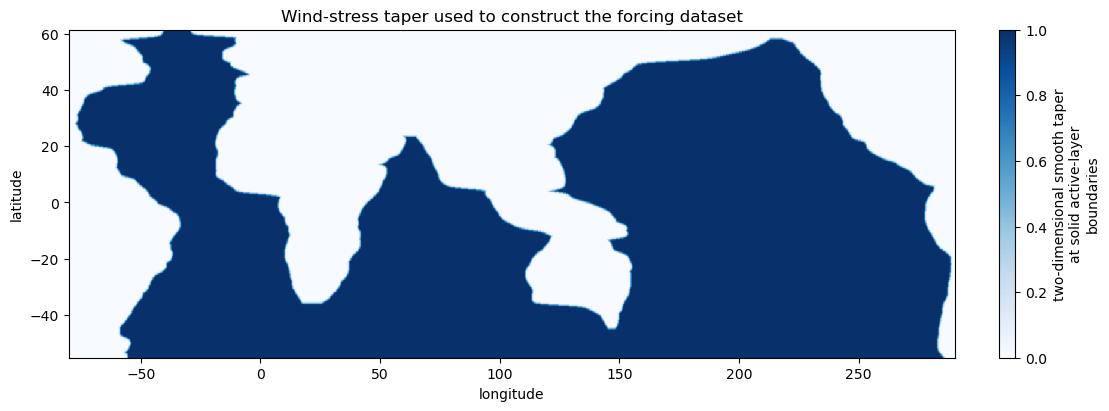

In [6]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
solid_boundary_taper.plot.pcolormesh(
    ax=ax, x="longitude", y="latitude", cmap="Blues", vmin=0.0, vmax=1.0
)
ax.set_title("Wind-stress taper used to construct the forcing dataset")
plt.show()

## Identify internal islands with GEBCO

The six single-valued isobath functions describe the true outer walls of the reduced model but deliberately omit islands. GEBCO is therefore used only to find land embedded well inside that active envelope.

For every ERA5 cell, the high-resolution source is reduced to two flags: whether the cell contains any land and whether it contains any bathymetry shallower than the 1000 m active-layer depth. Reading GEBCO one ERA5 latitude band at a time keeps peak memory small despite the native 15 arc-second grid.

Cells containing land farther than two degrees from the outer wall seed the inpainting mask. A one-cell shallow-water halo is added to keep the repaired stress smooth across mixed coastal cells.

In [7]:
def gebco_presence_on_grid(path, target_latitude, target_longitude, depth):
    """Return ERA5-cell land and shallow-water presence from native GEBCO.

    Each target cell is represented by all GEBCO samples in its rectangular
    footprint. Longitude windows wrap periodically so the unwrapped model grid
    can include both negative Atlantic and greater-than-180 Pacific values.
    """
    latitude_step = float(np.diff(target_latitude).min())
    longitude_step = float(np.diff(target_longitude).min())
    land = np.zeros((target_latitude.size, target_longitude.size), dtype=bool)
    shallow = np.zeros_like(land)

    with NetCDFDataset(path) as source:
        source_latitude = np.asarray(source.variables["lat"][:], dtype=float)
        source_longitude = np.asarray(source.variables["lon"][:], dtype=float)
        elevation = source.variables["elevation"]
        extended_longitude = np.concatenate(
            (source_longitude - 360.0, source_longitude, source_longitude + 360.0)
        )
        source_longitude_size = source_longitude.size
        wrapped_target = (target_longitude + 180.0) % 360.0 - 180.0
        longitude_windows = []
        for value in wrapped_target:
            lower = np.searchsorted(
                extended_longitude, value - longitude_step / 2.0, side="left"
            )
            upper = np.searchsorted(
                extended_longitude, value + longitude_step / 2.0, side="left"
            )
            longitude_windows.append(
                np.arange(lower, upper, dtype=int) % source_longitude_size
            )
        window_sizes = {window.size for window in longitude_windows}
        if len(window_sizes) != 1:
            raise RuntimeError("GEBCO longitude aggregation windows are inconsistent")
        longitude_windows = np.stack(longitude_windows)

        for row, value in enumerate(target_latitude):
            lower = np.searchsorted(
                source_latitude, value - latitude_step / 2.0, side="left"
            )
            upper = np.searchsorted(
                source_latitude, value + latitude_step / 2.0, side="left"
            )
            band = np.asarray(elevation[lower:upper, :])
            if band.size == 0:
                raise RuntimeError(f"GEBCO does not cover latitude {value}")
            land_by_longitude = np.any(band >= 0.0, axis=0)
            shallow_by_longitude = np.any(band >= -depth, axis=0)
            land[row] = land_by_longitude[longitude_windows].any(axis=1)
            shallow[row] = shallow_by_longitude[longitude_windows].any(axis=1)

    return land, shallow


land_presence, shallow_presence = gebco_presence_on_grid(
    GEBCO_PATH, latitude, longitude, H
)
distance_inside_active_layer = ndimage.distance_transform_edt(
    active_layer, sampling=(latitude_step, longitude_step)
)
outer_taper_width = 1.0 / TAPER_K
outside_outer_taper = np.isclose(solid_boundary_taper.values, 1.0)
interior_grid = np.ones_like(active_layer, dtype=bool)
interior_grid[[0, -1], :] = False
interior_grid[:, [0, -1]] = False
island_core = (
    land_presence
    & active_layer
    & outside_outer_taper
    & interior_grid
    & (distance_inside_active_layer > outer_taper_width)
)
island_mask = island_core | (
    ndimage.binary_dilation(island_core, structure=np.ones((3, 3), dtype=bool))
    & shallow_presence
    & active_layer
    & outside_outer_taper
    & interior_grid
    & (distance_inside_active_layer > outer_taper_width - latitude_step)
)

if np.any(island_mask & ~active_layer):
    raise AssertionError("Island inpainting mask extends outside the active layer")
if np.any(island_mask & ~outside_outer_taper):
    raise AssertionError("Island inpainting overlaps the outer-boundary taper")

_, island_component_count = ndimage.label(
    island_mask, structure=np.ones((3, 3), dtype=int)
)
print(
    f"inpainting {island_mask.sum():,} ERA5 cells in "
    f"{island_component_count:,} internal components"
)

inpainting 6,389 ERA5 cells in 332 internal components


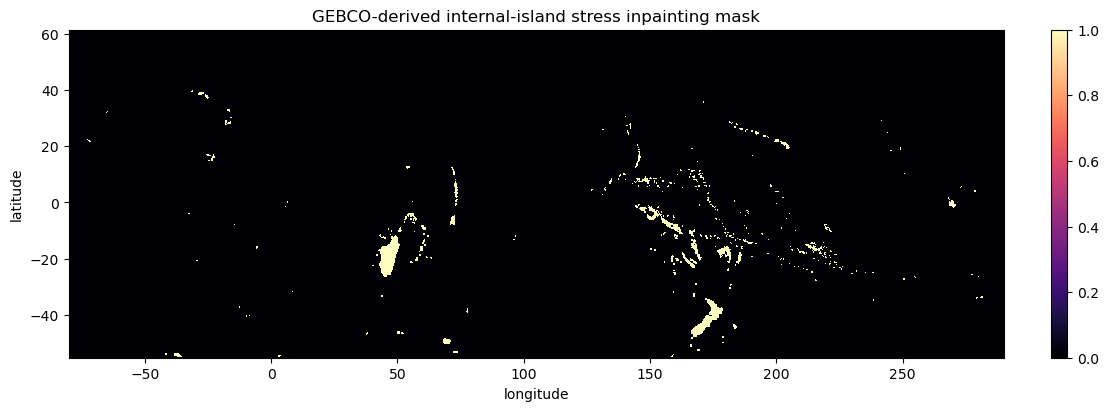

In [8]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
xr.DataArray(
    island_mask,
    dims=("latitude", "longitude"),
    coords={"latitude": latitude, "longitude": longitude},
).plot.pcolormesh(ax=ax, x="longitude", y="latitude", cmap="magma")
ax.set_title("GEBCO-derived internal-island stress inpainting mask")
plt.show()

## Harmonic extension of ERA5 stress

Each stress component satisfies a discrete Laplace equation inside the static island mask, with the surrounding ERA5 ocean stress as a Dirichlet boundary condition. This is a component-wise, linear interpolation; it neither damps nor changes valid ocean cells.

The sparse Laplacian and boundary lookup are precomputed once. Dask then evaluates twelve months and both stress components in each task, keeping the full preprocessing lazy through export.

In [9]:
def harmonic_inpainting_system(mask):
    """Build the sparse Laplacian and boundary lookup for a Boolean mask."""
    if mask.ndim != 2 or not np.any(mask):
        raise ValueError("mask must be a non-empty two-dimensional array")
    rows, columns = np.nonzero(mask)
    if (
        np.any(rows == 0)
        or np.any(rows == mask.shape[0] - 1)
        or np.any(columns == 0)
        or np.any(columns == mask.shape[1] - 1)
    ):
        raise ValueError("harmonic inpainting mask must not touch the grid edge")

    unknown_flat = np.flatnonzero(mask.ravel())
    unknown_lookup = np.full(mask.size, -1, dtype=int)
    unknown_lookup[unknown_flat] = np.arange(unknown_flat.size)
    equation = np.arange(unknown_flat.size)
    matrix_rows = [equation]
    matrix_columns = [equation]
    matrix_values = [np.full(unknown_flat.size, 4.0)]
    boundary_rows = []
    boundary_flat = []

    for row_offset, column_offset in ((-1, 0), (1, 0), (0, -1), (0, 1)):
        neighbour_flat = (
            (rows + row_offset) * mask.shape[1] + columns + column_offset
        )
        neighbour_unknown = unknown_lookup[neighbour_flat]
        internal = neighbour_unknown >= 0
        matrix_rows.append(equation[internal])
        matrix_columns.append(neighbour_unknown[internal])
        matrix_values.append(np.full(np.count_nonzero(internal), -1.0))
        boundary_rows.append(equation[~internal])
        boundary_flat.append(neighbour_flat[~internal])

    matrix = sparse.coo_matrix(
        (
            np.concatenate(matrix_values),
            (np.concatenate(matrix_rows), np.concatenate(matrix_columns)),
        ),
        shape=(unknown_flat.size, unknown_flat.size),
    ).tocsc()
    return (
        matrix,
        unknown_flat,
        np.concatenate(boundary_rows),
        np.concatenate(boundary_flat),
    )


def inpaint_stress_block(
    values,
    matrix,
    unknown_flat,
    boundary_rows,
    boundary_flat,
):
    """Harmonically extend one time block of vector stress across islands."""
    original_shape = values.shape
    flattened = values.reshape((-1, original_shape[-2] * original_shape[-1]))
    right_hand_side = np.zeros(
        (unknown_flat.size, flattened.shape[0]), dtype=np.float64
    )
    np.add.at(
        right_hand_side,
        boundary_rows,
        flattened[:, boundary_flat].T,
    )
    solution = spsolve(matrix, right_hand_side)
    output = values.copy()
    output.reshape(flattened.shape)[:, unknown_flat] = solution.T.astype(
        values.dtype, copy=False
    )
    return output


def lazy_inpainted_stress(values, mask, time_chunk=12):
    """Return a Dask array that inpaints vector stress in bounded time blocks."""
    matrix, unknown_flat, boundary_rows, boundary_flat = harmonic_inpainting_system(
        mask
    )
    rechunked = values.rechunk(
        {0: time_chunk, 1: -1, 2: -1, 3: -1}
    )
    delayed_blocks = rechunked.to_delayed().reshape(
        len(rechunked.chunks[0]), 1, 1, 1
    )[:, 0, 0, 0]
    output_blocks = []
    for block, count in zip(delayed_blocks, rechunked.chunks[0]):
        filled = delayed(inpaint_stress_block)(
            block,
            matrix,
            unknown_flat,
            boundary_rows,
            boundary_flat,
        )
        output_blocks.append(
            da.from_delayed(
                filled,
                shape=(count, values.shape[1], values.shape[2], values.shape[3]),
                dtype=values.dtype,
            )
        )
    return da.concatenate(output_blocks, axis=0)


stress = da.stack(
    (
        winds.avg_iews.transpose("time", "latitude", "longitude").data,
        winds.avg_inss.transpose("time", "latitude", "longitude").data,
    ),
    axis=1,
)
inpainted_stress = lazy_inpainted_stress(stress, island_mask)
winds_inpainted = xr.Dataset(
    {
        "avg_iews": (
            ("time", "latitude", "longitude"), inpainted_stress[:, 0]
        ),
        "avg_inss": (
            ("time", "latitude", "longitude"), inpainted_stress[:, 1]
        ),
    },
    coords={
        "time": winds.time,
        "latitude": winds.latitude,
        "longitude": winds.longitude,
    },
)
winds_anomaly = winds_inpainted - winds_inpainted.mean("time")
winds_anomaly

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 466, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 60.75 61.0 61.25
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    avg_iews   (time, latitude, longitude) float32 679MB dask.array<chunksize=(12, 466, 1481), meta=np.ndarray>
    avg_inss   (time, latitude, longitude) float32 679MB dask.array<chunksize=(12, 466, 1481), meta=np.ndarray>

## Convert tapered stress to vector Ekman transport

The taper is applied to the stress, before conversion. With eastward stress $\tau_x$ and northward stress $\tau_y$,

$$M_{\mathrm{Ek},x}=\frac{I_\gamma\tau_y}{\rho_0},\qquad M_{\mathrm{Ek},y}=-\frac{I_\gamma\tau_x}{\rho_0}.$$

The model can therefore derive both $w_{\mathrm{Ek}}=\nabla\cdot\mathbf M_{\mathrm{Ek}}$ and every Ekman section transport from the same two fields.

In [10]:
inverse_f = coriolis(winds_anomaly.latitude) / (
    coriolis(winds_anomaly.latitude) ** 2 + gamma**2
)
tau_x = winds_anomaly.avg_iews * solid_boundary_taper
tau_y = winds_anomaly.avg_inss * solid_boundary_taper

M_Ek_x_raw = tau_y * inverse_f / RHO_0
M_Ek_y_raw = -tau_x * inverse_f / RHO_0
M_Ek_x = (M_Ek_x_raw - M_Ek_x_raw.mean("time")).astype(np.float32).rename("M_Ek_x")
M_Ek_y = (M_Ek_y_raw - M_Ek_y_raw.mean("time")).astype(np.float32).rename("M_Ek_y")
T_N = (scotia_anomaly * 1e6).astype(np.float64).rename("T_N")

M_Ek_x.attrs = {
    "units": "m2 s-1",
    "long_name": "eastward Ekman transport anomaly",
    "positive": "eastward",
}
M_Ek_y.attrs = {
    "units": "m2 s-1",
    "long_name": "northward Ekman transport anomaly",
    "positive": "northward",
}
T_N.attrs = {
    "units": "m3 s-1",
    "long_name": "total northern Atlantic transport anomaly from SCOTIA",
    "positive": "northward",
    "latitude_degrees_north": ATLANTIC_NORTH,
}

forcing = xr.Dataset({"M_Ek_x": M_Ek_x, "M_Ek_y": M_Ek_y, "T_N": T_N})
forcing = forcing.transpose("time", "latitude", "longitude", missing_dims="ignore")
forcing.attrs.update(
    title="Global ERA5 Ekman transport and SCOTIA northern forcing anomalies",
    source_wind_stress="ERA5 monthly mean eastward/northward turbulent surface stress",
    source_northern_transport="SCOTIA overturning diagnostics MOC",
    source_geometry=ISOBATH_PATH.name,
    source_bathymetry=GEBCO_PATH.name,
    anomaly_reference="time mean over the common 2004-01 to 2024-06 monthly record",
    rho_0_kg_m3=RHO_0,
    g_prime_m_s2=G_PRIME,
    active_layer_depth_m=H,
    equatorial_cap_latitude_degrees=phi_c,
    equatorial_gamma_s_1=gamma,
    taper_k_per_degree=TAPER_K,
    taper_description="two-dimensional smooth stress taper at all solid active-layer boundaries; open boundaries untapered",
    generated_by="notebooks/construct_forcing_dataset_island_inpainted.ipynb",
    island_preprocessing="harmonic extension of ERA5 stress over GEBCO-resolved internal land before Ekman conversion",
    island_mask_cell_count=int(island_mask.sum()),
    island_mask_component_count=int(island_component_count),
    island_outer_buffer_degrees=outer_taper_width,
    island_shelf_halo_cells=1,
)
forcing

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 466, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 60.75 61.0 61.25
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 679MB dask.array<chunksize=(12, 466, 1481), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 679MB dask.array<chunksize=(12, 466, 1481), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/19)
    title:                            Global ERA5 Ekman transport and SCOTIA ...
    source_wind_stress:               ERA5 monthly mean eastward/northward tu...
    source_northern_transport:        SCOTIA overturning diagnostics MOC
    source_geometry:                  global_isobath_GEBCO_1000m.nc
    source_bathymetry:                GEBCO_2026_sub_ice.nc
    anomaly_reference:                time mean over the common 2004-01 to 20...
    ...                               ...
    generated_by:                     notebooks/construct_forcing_dataset_isl...
    island_preprocessing:             harmonic extension of ERA5 stress over ...
    island_mask_cell_count:           6389
    island_mask_component_count:      332
    island_outer_buffer_degrees:      2.0
    island_shelf_halo_cells:          1

## Contract checks and export

The canonical three-variable schema, dimensions, units, coordinates, finite values, and temporal anomaly contract are retained. Additional checks confirm that the GEBCO-derived mask does not overlap the true outer taper and that the preprocessing provenance is recorded.

The result is written to a separate file so the baseline forcing remains available for the comparison notebook.

In [11]:
if set(forcing.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
    raise AssertionError("Forcing dataset must contain exactly three variables")
for name in ("M_Ek_x", "M_Ek_y"):
    if forcing[name].dims != ("time", "latitude", "longitude"):
        raise AssertionError(f"Unexpected dimensions for {name}")
    if forcing[name].attrs["units"] != "m2 s-1":
        raise AssertionError(f"Unexpected units for {name}")
if forcing.T_N.dims != ("time",) or forcing.T_N.attrs["units"] != "m3 s-1":
    raise AssertionError("Unexpected T_N contract")
if forcing.T_N.attrs["latitude_degrees_north"] != ATLANTIC_NORTH:
    raise AssertionError("T_N has the wrong prescribed latitude")
if not forcing.time.equals(scotia.time):
    raise AssertionError("Forcing variables do not use the SCOTIA time grid")
if not np.all(np.diff(forcing.latitude) > 0) or not np.all(np.diff(forcing.longitude) > 0):
    raise AssertionError("Spatial coordinates must be strictly increasing")
if not np.isclose(float(forcing.T_N.mean()), 0.0, atol=1e-8):
    raise AssertionError("T_N is not a zero-mean anomaly")
M_Ek_time_means = dask.compute(
    abs(forcing.M_Ek_x.astype(np.float64).mean("time")).max(),
    abs(forcing.M_Ek_y.astype(np.float64).mean("time")).max(),
)
if max(map(float, M_Ek_time_means)) >= 1e-7:
    raise AssertionError(f"M_Ek anomaly mean is too large: {M_Ek_time_means}")

outside = solid_boundary_taper == 0.0
outside_sample = forcing[["M_Ek_x", "M_Ek_y"]].isel(time=[0, -1]).where(outside, 0.0)
if any(float(abs(outside_sample[name]).max().compute()) != 0.0 for name in outside_sample):
    raise AssertionError("Ekman transport is non-zero outside the tapered domain")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
temporary_path = OUTPUT_PATH.with_name(f"{OUTPUT_PATH.stem}.tmp{OUTPUT_PATH.suffix}")
if temporary_path.exists():
    temporary_path.unlink()

n_time = forcing.sizes["time"]
encoding = {
    "M_Ek_x": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": None,
    },
    "M_Ek_y": {
        "dtype": "float32",
        "compression": "gzip",
        "compression_opts": 2,
        "shuffle": True,
        "chunksizes": (n_time, 16, 64),
        "_FillValue": None,
    },
    "T_N": {"dtype": "float64", "_FillValue": None},
}
write = forcing.to_netcdf(
    temporary_path, engine="h5netcdf", encoding=encoding, compute=False
)
with dask.config.set(scheduler="threads", num_workers=4), ProgressBar():
    write.compute()
temporary_path.replace(OUTPUT_PATH)
print(f"Wrote {OUTPUT_PATH} ({OUTPUT_PATH.stat().st_size / 1e9:.2f} GB)")

[                                        ] | 0% Completed | 99.42 us

[                                        ] | 0% Completed | 147.65 ms

[                                        ] | 0% Completed | 316.52 ms

[                                        ] | 0% Completed | 681.97 ms

[                                        ] | 1% Completed | 786.67 ms

...

[####################################### ] | 99% Completed | 165.64 s

[####################################### ] | 99% Completed | 165.75 s

[####################################### ] | 99% Completed | 165.85 s

[########################################] | 100% Completed | 165.95 s

Wrote /private/tmp/MOCAdjustmentTheory-island-inpaint/data/untracked/forcing/global_ERA5_SCOTIA_forcing_island_inpainted.nc (0.65 GB)


In [12]:
with xr.open_dataset(OUTPUT_PATH, engine="h5netcdf", chunks={}) as exported:
    if set(exported.data_vars) != {"M_Ek_x", "M_Ek_y", "T_N"}:
        raise AssertionError("Exported file has the wrong variables")
    if exported.sizes != forcing.sizes:
        raise AssertionError("Exported file has the wrong dimensions")
    if exported.T_N.attrs.get("latitude_degrees_north") != ATLANTIC_NORTH:
        raise AssertionError("Exported T_N latitude metadata was not preserved")
    sample = exported[["M_Ek_x", "M_Ek_y", "T_N"]].isel(
        time=[0, -1], latitude=[0, exported.sizes["latitude"] // 2, -1], longitude=[0, exported.sizes["longitude"] // 2, -1], missing_dims="ignore"
    ).load()
    if bool(sample.to_array().isnull().any()):
        raise AssertionError("Exported sample contains missing values")
    if "harmonic extension" not in exported.attrs.get("island_preprocessing", ""):
        raise AssertionError("Exported island-preprocessing provenance is missing")
    print(exported)
    print("schema, provenance, and finite-value sample verified")

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 246, latitude: 466, longitude: 1481)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2004-01-01 2004-02-01 ... 2024-06-01
  * latitude   (latitude) float64 4kB -55.0 -54.75 -54.5 ... 60.75 61.0 61.25
  * longitude  (longitude) float64 12kB -80.0 -79.75 -79.5 ... 289.5 289.8 290.0
Data variables:
    M_Ek_x     (time, latitude, longitude) float32 679MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    M_Ek_y     (time, latitude, longitude) float32 679MB dask.array<chunksize=(246, 16, 64), meta=np.ndarray>
    T_N        (time) float64 2kB dask.array<chunksize=(246,), meta=np.ndarray>
Attributes: (12/19)
    title:                            Global ERA5 Ekman transport and SCOTIA ...
    source_wind_stress:               ERA5 monthly mean eastward/northward tu...
    source_northern_transport:        SCOTIA overturning diagnostics MOC
    source_geometry:                  global_isobath_GEBCO_1000m.nc
    source_bathymetry:   